# Successor Representation Model Simulations

# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sr

In [96]:
importlib.reload(sr)

<module 'sr' from '/n/data2/hms/neurobio/harvey/Henry/courses/neuro_1401/hpc_sr/sr.py'>

# Environment

In [2]:
N = 30
gamma = 0.90
p_right = 0.85

In [3]:
env = sr.Ring(n=N, p_right=p_right)

In [87]:
env2 = sr.LinearTrack(n=N, p_right=p_right)

# Perturbation 1: Reward Introduction

## Baseline before reward

In [28]:
M1 = sr.compute_sr(env.trans, gamma)
s = 15

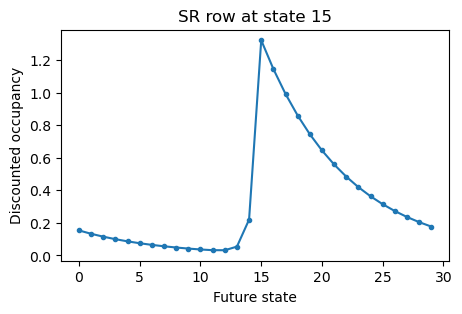

In [29]:
fig1a, ax1a = sr.plot_sr_row(M1, s, figsize=(5, 3))
plt.show()

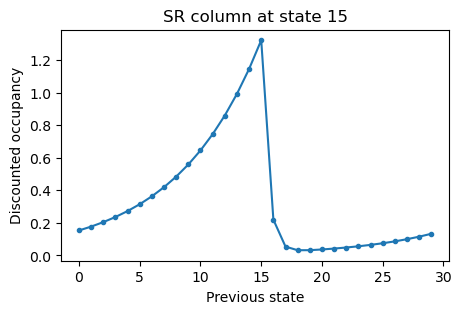

In [30]:
fig1b, ax1b = sr.plot_sr_column(M1, s, figsize=(5, 3))
plt.show()

## After reward introduction

In [41]:
reward_loc = 25
reward = np.zeros(N)
reward[reward_loc] = 1
value = np.dot(M1, reward)
beta = 15
policy_1 = sr.compute_softmax_policy(env.adj, value, beta)
M1b = sr.compute_sr(policy_1, gamma)

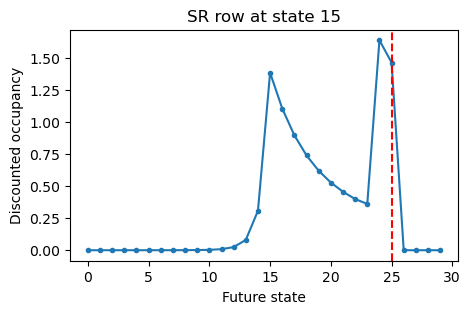

In [42]:
fig1c, ax1c = sr.plot_sr_row(M1b, s, reward_loc, figsize=(5, 3))
plt.show()

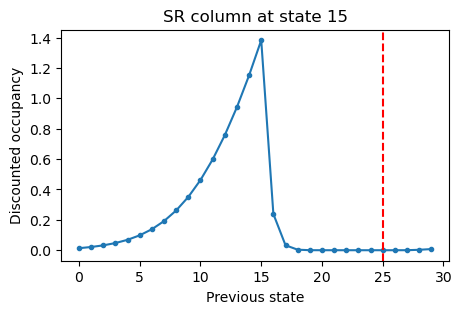

In [43]:
fig1d, ax1d = sr.plot_sr_column(M1b, s, reward_loc, figsize=(5, 3))
plt.show()

## Comparison

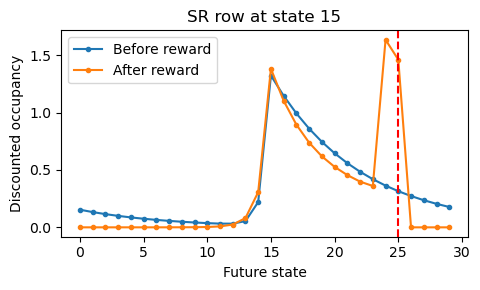

In [109]:
fig1e, ax1e = sr.plot_sr_row_comp([M1, M1b], s, reward_loc, figsize=(5, 3), labels=['Before reward', 'After reward'])
plt.tight_layout()
plt.savefig('./plots/SR_row_vector_before_vs_after_reward.pdf', dpi=300)
plt.show()

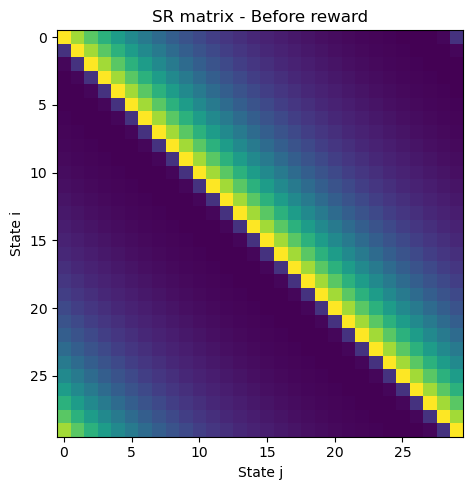

In [114]:
fig1f, ax1f = sr.plot_sr_matrix(M1, figsize=(5, 5), title='SR matrix - Before reward')
plt.tight_layout()
plt.savefig('./plots/SR_matrix_before_reward.pdf', dpi=300)
plt.show()

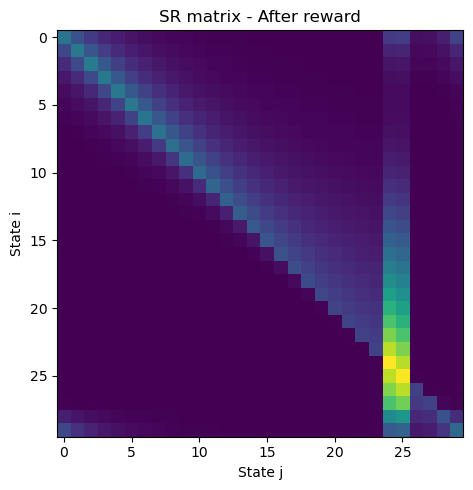

In [115]:
fig1g, ax1g = sr.plot_sr_matrix(M1b, figsize=(5, 5), title='SR matrix - After reward')
plt.tight_layout()
plt.savefig('./plots/SR_matrix_after_reward.pdf', dpi=300)
plt.show()

# Perturbation 2: Reward Location Switch

In [50]:
M2 = M1b.copy()
reward_loc_new = 15
reward_new = np.zeros(N)
reward_new[reward_loc_new] = 1
n_trials = 200
n_steps = 50
a = 0.1

M2_early = np.zeros((N,N))
M2_mid = np.zeros((N,N))

for t in range(n_trials):
    value_new = np.dot(M2, reward_new)
    policy_2 = sr.compute_softmax_policy(env.adj, value_new, beta)
    
    traj = sr.sample_trajectory(policy_2, start_state=0, n_steps=n_steps)

    for curr_state, next_state in zip(traj[:-1], traj[1:]):
        e = np.zeros(N)
        e[curr_state] = 1
        d = e + gamma * M2[next_state,:] - M2[curr_state,:]
        M2[curr_state,:] += a*d
    
    if t == 0:
        M2_early = M2.copy()
    elif t == n_trials//2:
        M2_mid = M2.copy()

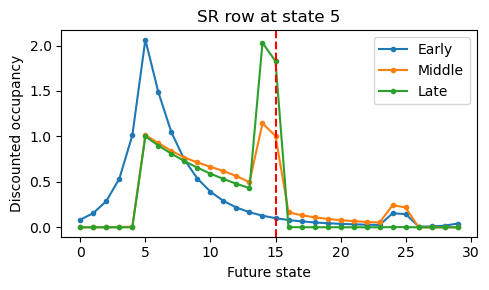

In [102]:
fig2a, ax2a = sr.plot_sr_row_comp([M2_early, M2_mid, M2], 5, reward_loc_new, figsize=(5, 3), labels=['Early', 'Middle', 'Late'])
plt.tight_layout()
plt.savefig('./plots/SR_row_vector_reward_location_switch_across_learning.pdf', dpi=300)
plt.show()

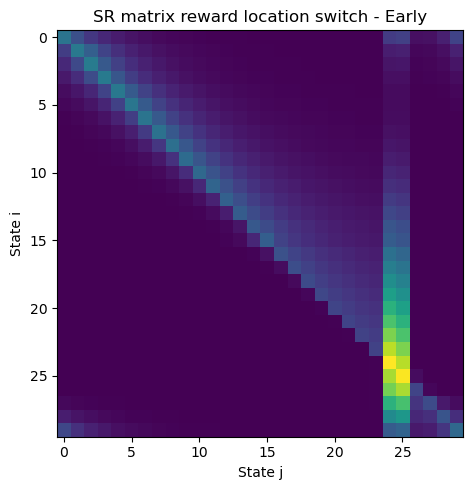

In [117]:
fig2b, ax2b = sr.plot_sr_matrix(M2_early, figsize=(5, 5), title='SR matrix reward location switch - Early')
plt.tight_layout()
plt.savefig('./plots/SR_matrix_reward_location_switch_early.pdf', dpi=300)
plt.show()

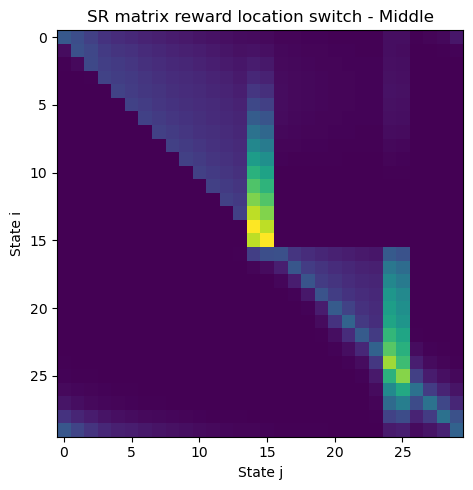

In [118]:
fig2c, ax2c = sr.plot_sr_matrix(M2_mid, figsize=(5, 5), title='SR matrix reward location switch - Middle')
plt.tight_layout()
plt.savefig('./plots/SR_matrix_reward_location_switch_middle.pdf', dpi=300)
plt.show()

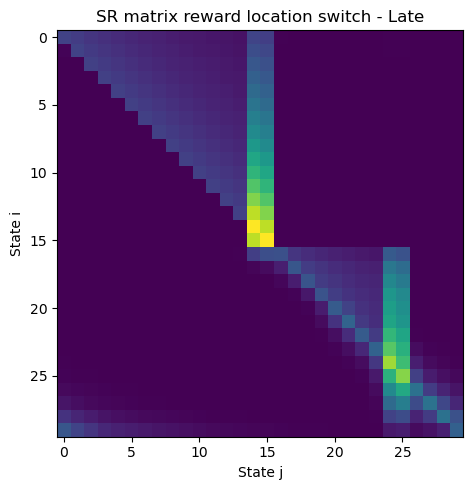

In [119]:
fig2c, ax2c = sr.plot_sr_matrix(M2, figsize=(5, 5), title='SR matrix reward location switch - Late')
plt.tight_layout()
plt.savefig('./plots/SR_matrix_reward_location_switch_late.pdf', dpi=300)
plt.show()

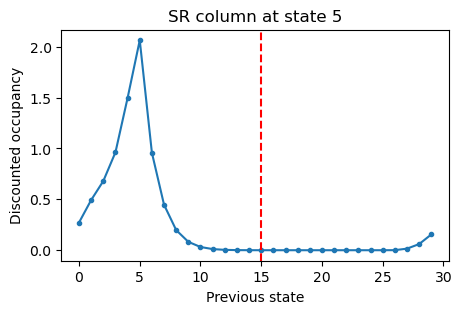

In [64]:
fig2d, ax2d = sr.plot_sr_column(M2_early, 5, reward_loc_new, figsize=(5, 3))
plt.show()

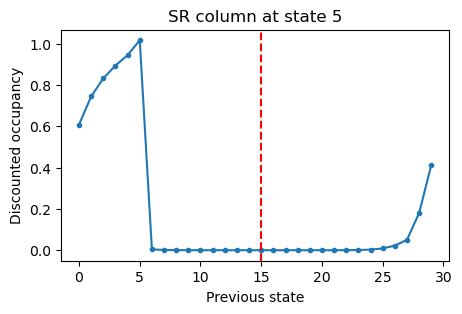

In [65]:
fig2e, ax2e = sr.plot_sr_column(M2_mid, 5, reward_loc_new, figsize=(5, 3))
plt.show()

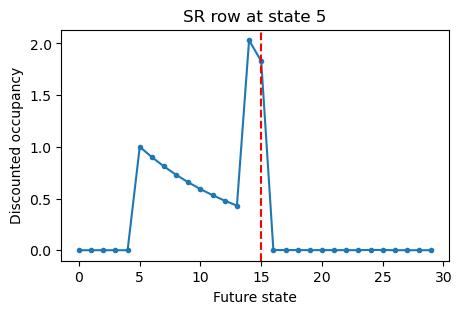

In [67]:
fig2f, ax2f = sr.plot_sr_row(M2, 5, reward_loc_new, figsize=(5, 3))
plt.show()

# Perturbation 3: Teleport Forward vs. Backward

In [84]:
start_states = range(5, N-5)
distances = [2, 4, 6]

results = []

for start_state in start_states:
    for dist in distances:
        s_fwd = (start_state + dist) % N
        s_bwd = (start_state - dist) % N

        td_fwd = np.linalg.norm(sr.sr_td_error(M1, start_state, s_fwd, gamma))
        td_bwd = np.linalg.norm(sr.sr_td_error(M1, start_state, s_bwd, gamma))

        results.append([start_state, dist, td_fwd, td_bwd, td_bwd - td_fwd])

results = np.array(results)


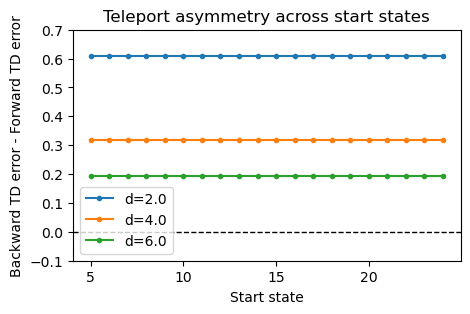

In [86]:
fig3a, ax3a = sr.plot_teleport_asymmetry(results)
ax3a.set_xticks(np.arange(5, N-5, 5))
ax3a.set_ylim(-0.1, 0.7)
plt.show()

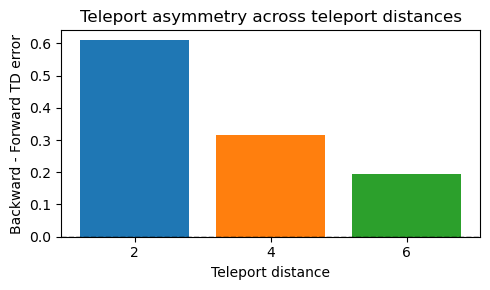

In [110]:
sr.plot_teleport_asymmetry_bar(results)
plt.tight_layout()
plt.savefig('./plots/SR_teleport_asymmetry_bar.pdf', dpi=300)
plt.show()